In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pickle import load

## **Data Ingestion**

In [25]:
df = pd.read_csv(r"C:\Users\Win 10\Desktop\kh\kharidyar-chatbot\Datasets\intention_dataset.csv")

In [26]:
df

,text,label
0,تمایل دارم از به‌روزرسانی‌های مربوط به مرحله‌ا...,tracking
1,ایا درگاه پشتیبانی مشتری وجود دارد ؟,customer-service
2,میخوام بدونم قیمت پنیر 14 چقدر میشه؟,inquiring
3,آیا می‌توانم در مورد زمان تقریبی رسیدن بسته‌ام...,tracking
4,لطفا فرآیند تسویه حکم 1538 را شروع کنید.,deleting
...,...,...
3909,خدا تو را حفظ کند,chitchat
3910,چطور مطوری؟,chitchat
3911,من به دنبال نان هستم، آیا آنها را در گرم حمل م...,buying
3912,مچکرم ازت زحمتت دادم,chitchat


## **Data Analysis**

Text(0.5, 0.98, 'Label Counts')

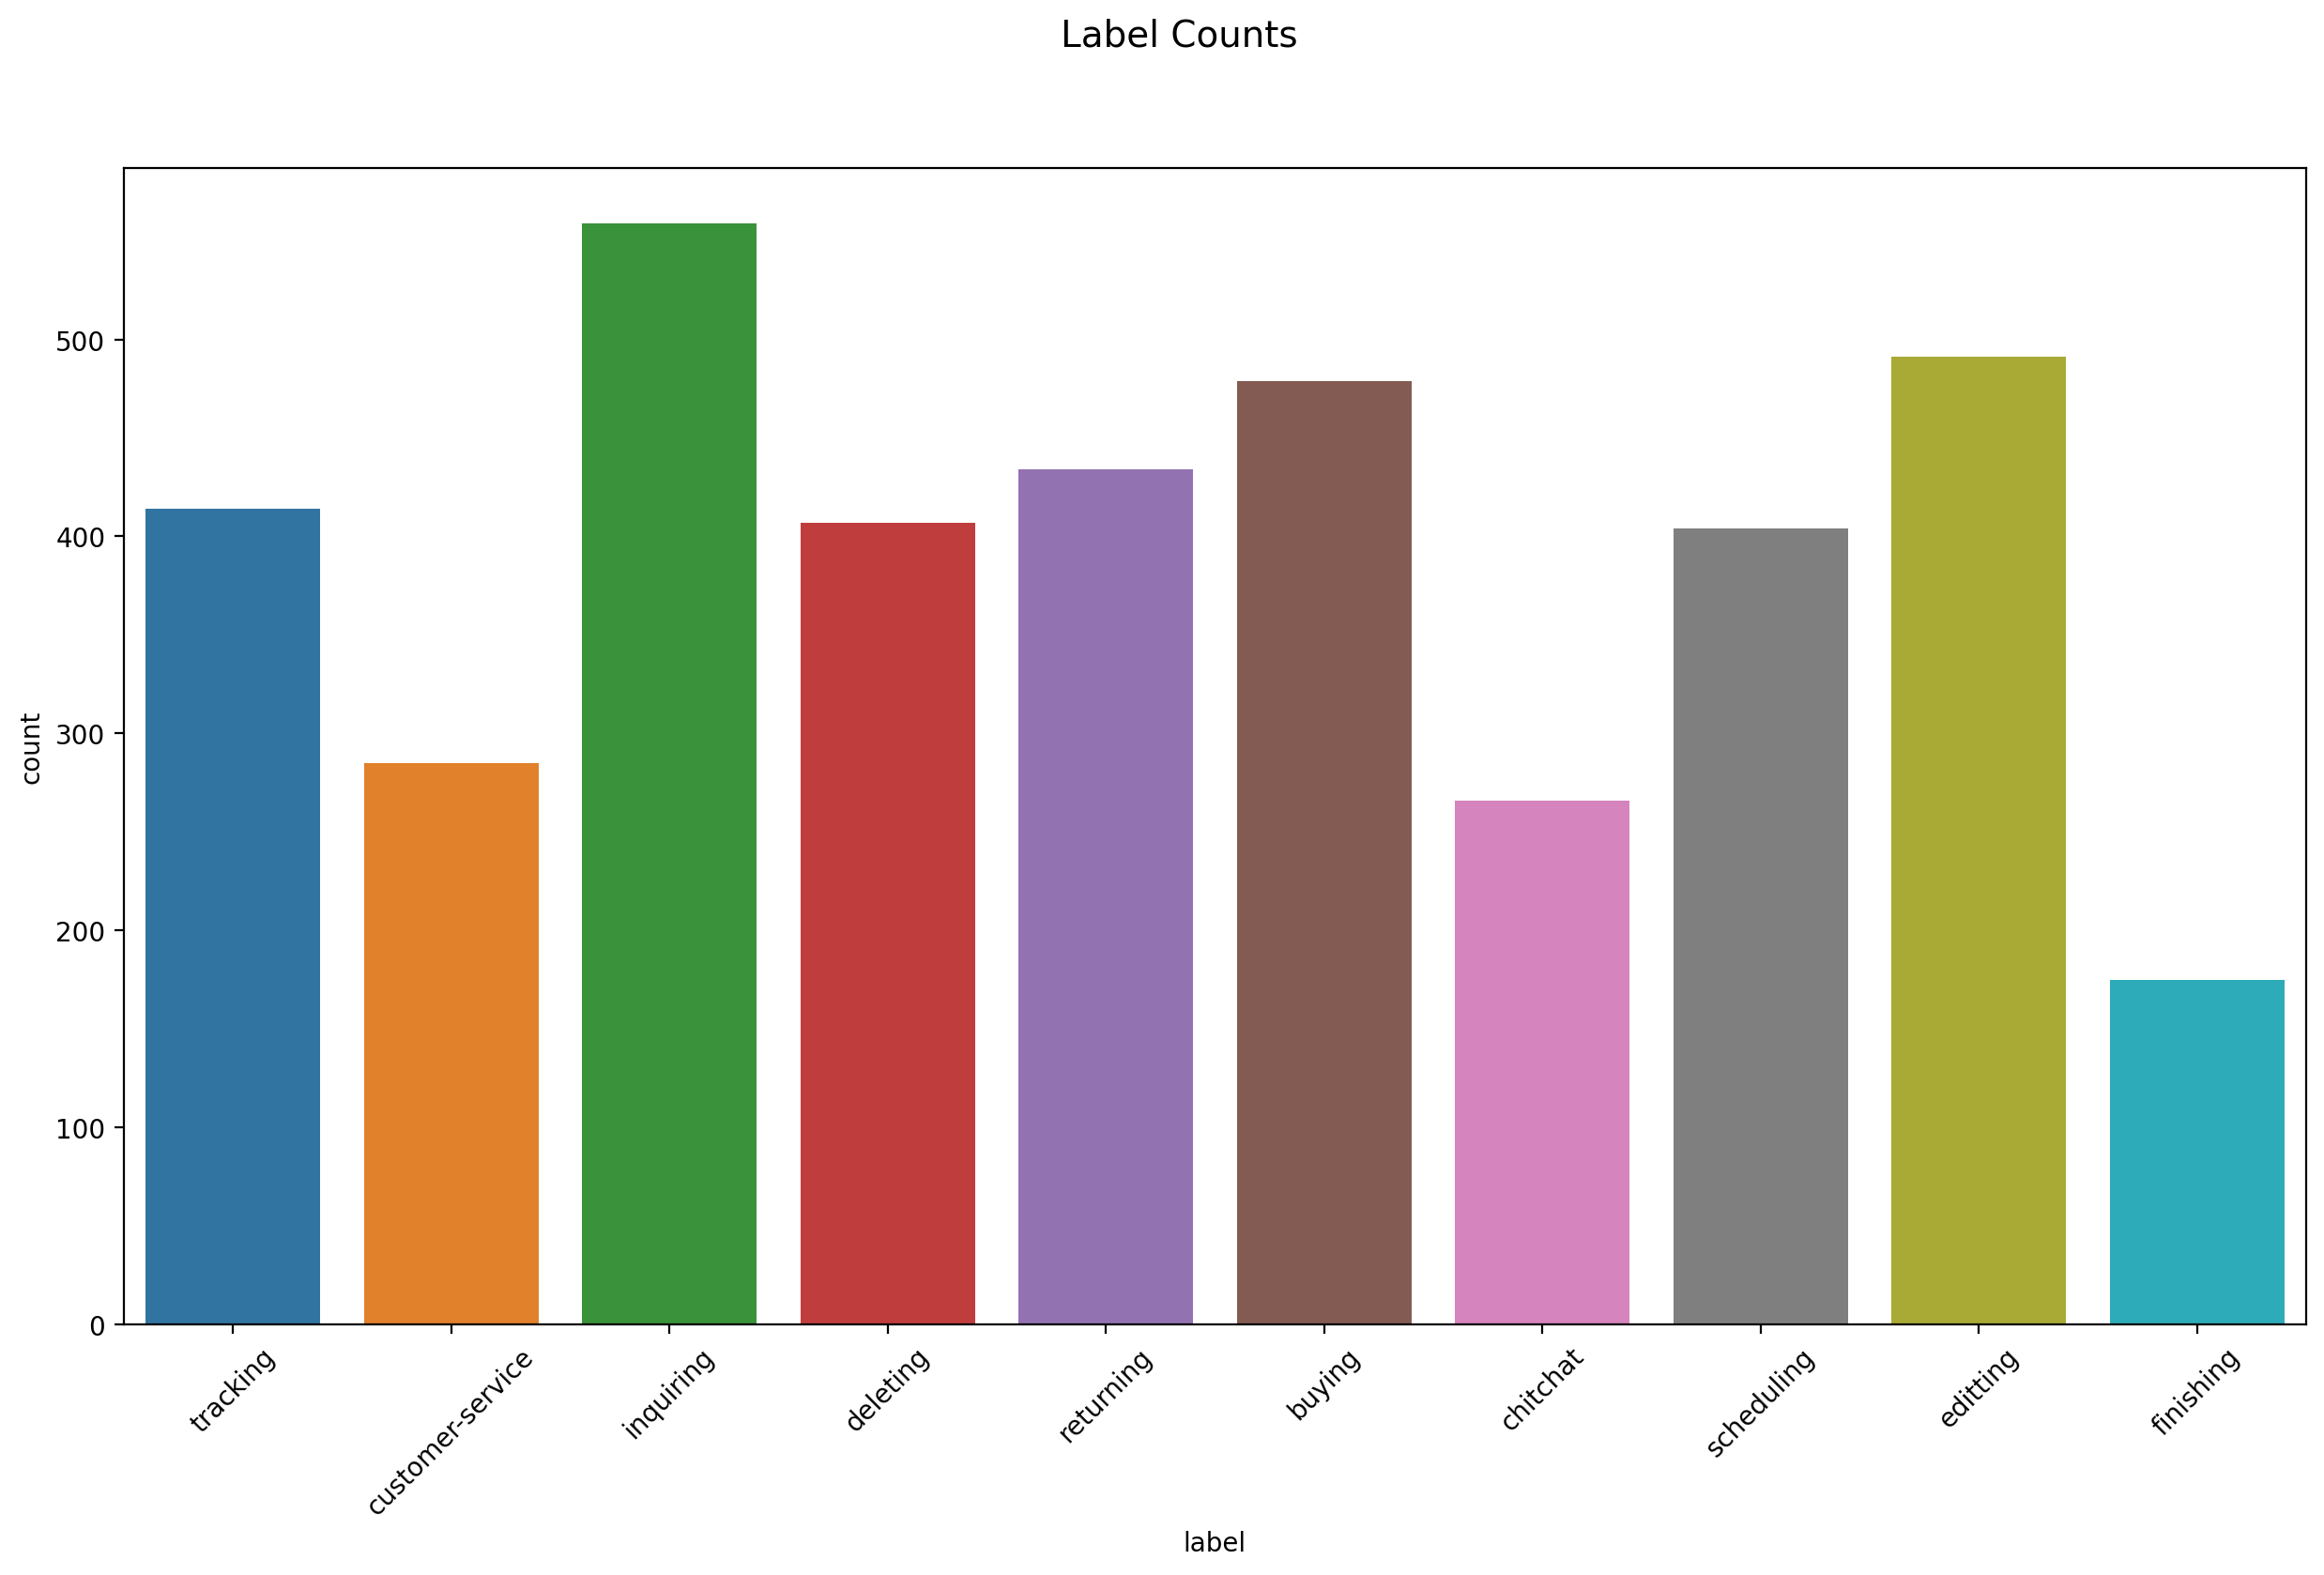

In [27]:
plt.figure(figsize=(15, 8), dpi=200)
sns.countplot(data=df, x="label")
plt.xticks(rotation=45)
plt.suptitle("Label Counts", size=14)

In [28]:
df["number_of_token"] = df["text"].apply(lambda x: len(x.split(" ")))
df["text_length"] = df["text"].apply(lambda x: len(x))

Text(0.5, 0.98, 'Boxen Plot of Tokens')

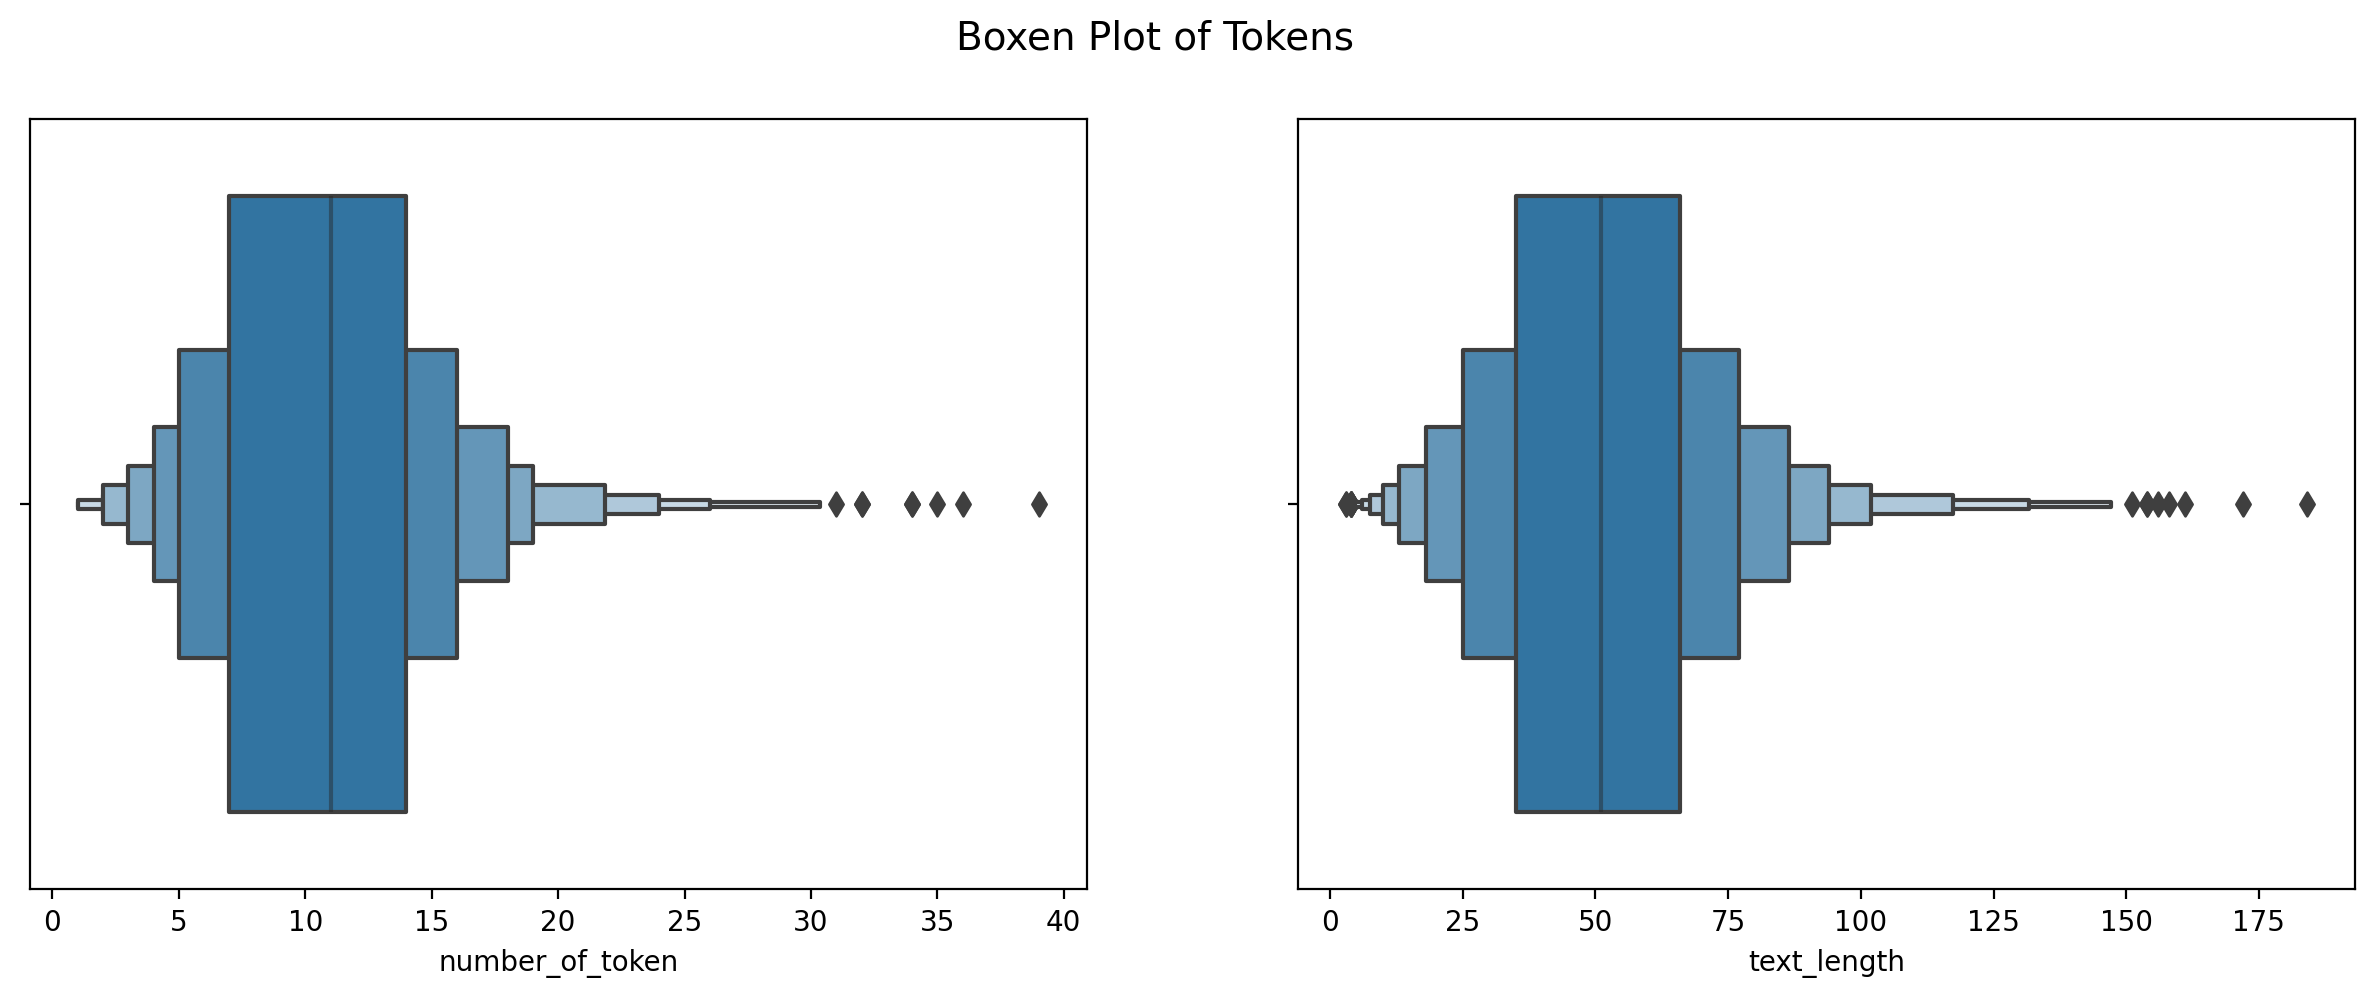

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=200)
sns.boxenplot(data=df, x="number_of_token", ax=axes[0])
sns.boxenplot(data=df, x="text_length", ax=axes[1])
plt.suptitle("Boxen Plot of Tokens", size=14)

Text(0.5, 0.98, 'KDE Plot of Tokens')

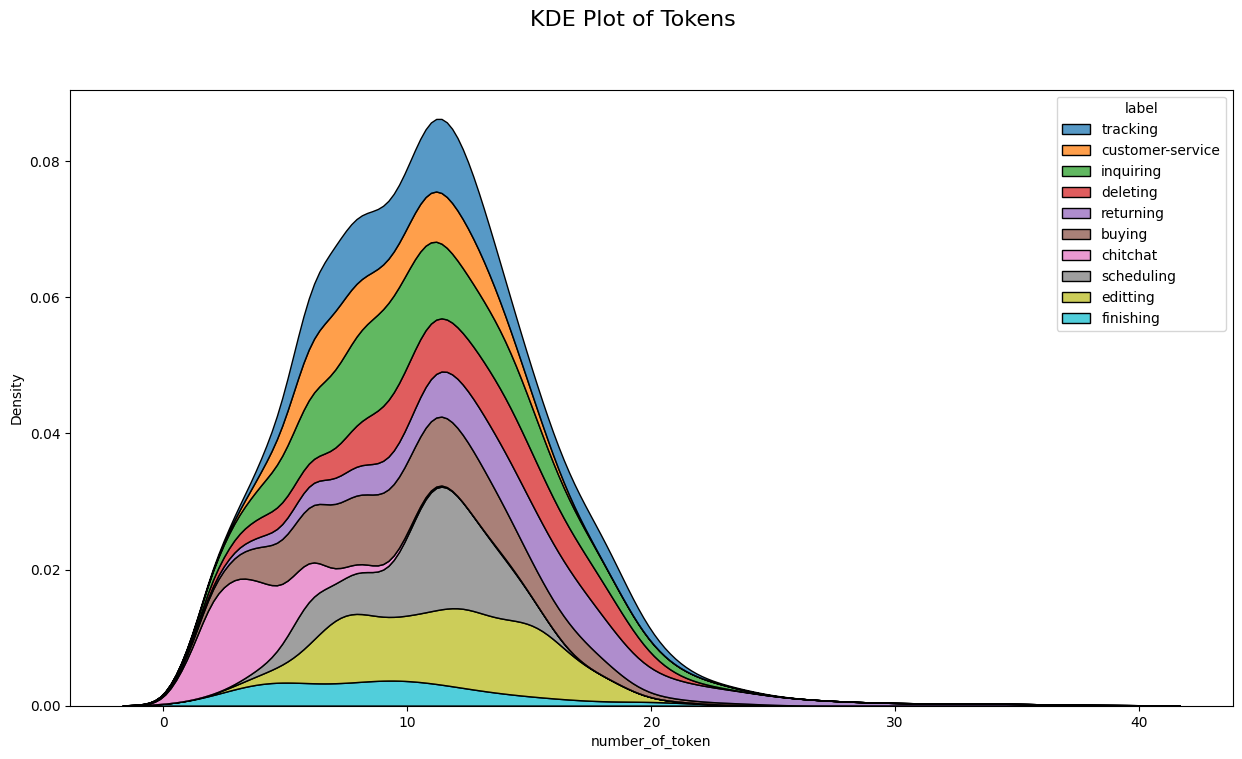

In [30]:
plt.figure(figsize=(15, 8), dpi=100)
sns.kdeplot(data=df, x="number_of_token", hue="label", multiple="stack")
plt.suptitle("KDE Plot of Tokens", size=16)

## **Token Analysis**

In [31]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
cv_1 = CountVectorizer(max_df=0.005)
cv_2 = CountVectorizer(ngram_range=(1, 2), max_df=0.01)
vect_1 = cv_1.fit_transform(df["text"]).toarray()
vect_2 = cv_2.fit_transform(df["text"]).toarray()

In [32]:
print(f"Vocab size (1-garam): {vect_1.shape[1]}")
print(f"Vocab size (2-garam): {vect_2.shape[1]}")

Vocab size (1-garam): 1546
Vocab size (2-garam): 10015


## **Test The Model**

In [46]:
with open(r"C:\Users\Win 10\Desktop\kh\kharidyar-chatbot\Models\intention_recognizer_model_2.pkl", "rb") as f:
    intent_classifier = load(f)

In [47]:
from preprocessor import Preproccessing
p = Preproccessing(stemming=False)

In [52]:
intent_classifier.predict([p.fit("سفارشم رو مرجوع کن")])

array(['returning'], dtype=object)

## **Hyperparameter Tuning**

In [71]:
data = pd.read_excel(r"C:\Users\Win 10\Desktop\kh\kharidyar-chatbot\Results\hyperparameter_tuning_intention_model.xlsx")
data.drop(["Unnamed: 0", "std_test_score"], axis=1, inplace=True)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le_2 = LabelEncoder()

data.loc[:, "param_classifier__loss"] = le.fit_transform(data["param_classifier__loss"])
data.loc[:, "param_vectorizer__ngram_range"] = le_2.fit_transform(data["param_vectorizer__ngram_range"])

data["param_classifier__loss"] = data["param_classifier__loss"].astype(np.int32)
data["param_vectorizer__ngram_range"] = data["param_vectorizer__ngram_range"].astype(np.int32)


data.dropna(inplace=True)

In [74]:
import plotly.express as px

fig = px.parallel_coordinates(
    data, 
    color="mean_test_score",
    labels={
        "mean_test_score": "Accuracy",
        "param_classifier__loss": "Loss Function",
        "param_vectorizer__ngram_range": "Ngram Range",
        "param_vectorizer__max_df": "Max Document Frequency",
        "param_classifier__C": "Lambda"
    },
    color_continuous_scale=px.colors.diverging.Tealrose,
    color_continuous_midpoint=0.96,
    width=1280, 
    height=720
)
fig.show()